# 1~2장 -> 전반적인 설명 + 이후 내용에서 자주 사용되고, 필수로 알아야 하는 내용 정리

### 딥러닝 모델의 주요 구성 요소
- 데이터 :
    - 모델이 패턴을 학습할 수 있도록 하는 대량의 데이터 집합.

- 신경망 :
    - 입력층, 은닉층, 출력층으로 구성된 다층 신경망 구조

- 손실함수(Loss function) :
    - 모델의 예측과 실제 값 간의 차이를 측정하는 함수.

- 최적화(Optimizer) :
    - 손실함수를 최소화하기 위해 모델 가중치를 조정하는 알고리즘

- 활성화 함수(Activaton function) :
    - 신경망에 비선형성을 제공해 복잡한 패턴을 학습할 수 있게 변환

### 어텐션 메커니즘
- 쿼리(벡터)
    - 현재 위치에서 관심 있는 부분을 나타내는 벡터
    - 현재 처리 중인 단어에 대한 정보

- 키(벡터)
    - 각 위치에 대한 정보를 나타내는 벡터
    - 입력 시퀀스의 각 단어를 나타내는 값 

- 값(벡터)
    - 각 위치에 대한 값 벡터
    - 키와 연관된 정보를 담고 있는 벡터

### 허깅페이스 허브
- 머신러닝 모델, 데모, 데이터 세트 및 메트릭을 공유하는 플랫폼
- AI계의 깃허브
- 검색 기능을 통해 원하는 모델과 데이터세트를 쉽게 찾음
- 모델과 데이터세트에 대한 메타데이터와 가이드 문서가 제공
    - 사용 방법을 이해하기 쉽다
- 모델과 데이터세트의 버전 관리도 지원
- 모델과 데이터세트를 직접 다운로드 가능 

### 허깅페이스 모델 업로드
- 대표적으로 2가지의 방식을 사용함
    - push_to_hub 메서드
        - 허깅페이스 내장 라이브러리로 자동화 
    - Git
        - Git LFS 활용(대용량 모델)



```python
객체(클래스명).push_to_hub(
    # push할 저장소 이름, 조직:"abc"이고, 저장소:"def"이면, "abc/def"라고 하면됨
    repo_id : str 

    # push전에 저장된 파일을 임시 dir에 저장할지 여부, repo_id와 같은 dir이 없으면 True로 설정.
    use_temp_dir : Optional[bool] = None,

    # 원격 파일에 댛나 HTTP Bearer 인증으로 사용할 토큰, 허깅페이스 토큰을 입력해 계정 인증 가능함.
    token: Optional[Union[bool, str]] = None,

    # model에만 사용되는 매개변수, 분할되기 전의 체크포인트의 최대 크기,
    # 모델의 크기가 5GB보다 크면 이를 여러개의 작은 체크포인트로 나눠 저장함 -> 큰 모델도 관리 가능한 크기로 분할 저장함.
    max_shard_size: Optional[Union[int, str]] = "5GB",

    # 모델 가중치를 Safetensors 형식으로 변환할지 설정.
    # True -> Safetensor으로 변경되어 메모리 효율성과 보안성 향상,
    # False -> 기존 파이토치 또는 텐서플로 형식 그대로 모델 가중치 업로드
    safe_serialization: bool = True,

    # 저장소를 비공개 저장소로 생성할지 여부. 
    private: Optional[bool] = None,

    # 업로드된 파일을 push할 브랜치 설정
    revision: str = None,

    # 커밋 메시지 -> 기본값 "Upload {object}"
    commit_message: Optionalfstr] = None,

    # 생성될 커밋의 설명
    commit_description: str = None,

    # 업로드된 파일로 PR을 만들지 또는 직접 커밋할지 결정
    create_pr： bool = False,
    
    # 허브에 push할 태그 목록 설정 
    tags: Optional[List[str]] = None
)
```


### 허깅페이스 데이터셋
- 다양한 데이터 형식 지원
    - 텍스트 파일, 이미지 파일, 오디오 파일, CSV, JSON, Arrow, Parquet 등 다양한 데이터 형식을 읽어와 머신러닝에 사용 가능하도록 변환

- 데이터 분할 
    - 학습, 검증, 테스트 세트로 데이터 세트를 쉽게 분할 가능.
    - 데이터 분할시 비율을 직접 지정해 분할하거나, 데이터 세트 허브에 분할된 채로 제공되는 데이터를 바로 불러와 사용 가능

- 데이터 버전 관리
    - 데이터 세트의 버전을 지정, 관리 가능
    - 다양한 환경과 시점에 학습해도 데이터의 재현성(Reproducilbilit)를 보장

- 전처리 기능
    - 데이터 필터링, 토큰화, 패딩, 정규화, 데이터 증강 등 다양한 전처리 기능 제공

- 병렬 처리
    - 데이터를 전처리할 때, 병렬 처리 및 배치 처리를 지원해 빠르게 처리 가능

- **스트리밍 처리**
    - 데이터 세트가 너무 커서 한정된 메모리에서 한번에 처리할 수 없는 경우, 스트리밍 방식을 통해 메모리를 절약하여 처리
    - 스트리밍 사용시 SSD로 가지않고, RAM으로 가서 메모리의 수명에 오히려 좋다. (RAM은 반영구적임)

### 허깅페이스 생태계 구성 라이브러리
#### 1. 트랜스포머
- 핵심 모델들을 불러오는 라이브러리

#### 2. 토크나이저(Tokenizer)
- 자연어 전처리를 담당하는 라이브러리

#### 3. 데이터세트(Datasets)
- 대규모 데이터를 다루는 라이브러리

#### 4. 디퓨저(Diffusers)
- 이미지 생성 모델을 다루는 라이브러리

#### 5. 가속화(Accelerate)
- 분산 학습과 하드웨어 가속을 돕는 라이브러리
- FP16 , BF16 등

### Config 클래스
1. ***PretrainedConfig -> 기본 설정 클래스***
    - 사전 학습된 모델들의 구성을 정의하는 가장 기본이 되는 부모클래스
2. ***ModelConfig -> 특정 모델 전용 설정 클래스***
    - 기본(PretrainedConfig)클래스를 상속받아 각 모델 아키텍처에 맞게 특정한 설정을 추가로 정의한 전용 클래스
    - BertConfig 
        - BERT 모델 전용 설정 클래스
        - 명시적으로 BERT모델의 설정을 생성할 때 사용
        - 모델의 정의하는 코드를 더 구조화되고 명확하게 만들어줌
    - GPT2Config
        - GPT-2 모델의 구조와 설정을 정의할 때 사용되는 전용 클래스
3. ***AutoConfig -> 자동화 설정 클래스***
    - 사용자의 편의성을 극대화하기 위해 등장한 오토(Auto)클래스 중 하나
    - 사용자가 모델 아키텍처의 세부사항이나 전용 config 클래스 이름을 몰라도 쉽게 모델 설정을 불러올 수 있게 해줌
4. ***GPTQConfig -> 양자화 설정 클래스***
    - 특수 목적의 설정 클래스
    - 대규모 언어 모델의 크기를 줄이고, 추론 속도를 높이기 위한 기술인 **모델 양자화(Quantization)**를 수행할 때 사용되는 설정 클래스

### PretrainedConfig 클래스

- 모델의 구조와 하이퍼파라미터를 저장하는 딕셔너리를 포함
- 허깅페이스의 사전 학습된 모델들에서 공통으로 사용되는 기본 구성 클래스
- 모델의 구조와 하이퍼파라미터를 간편하게 정의하고 관리함

```python
config = transformers.PretrainedConfig(
    # 모델 유형 -> gpt2 등등
    model_type: str,
    # 모델의 어휘 사전, 모델이 인식할 수 있는 고유 토큰의 수 결정
    vocab_size: int,
    # 모델의 은닉 계층에 있는 노드의 수, 클수록 모델의 표현능력이 높아짐
    hidden_size: int,
    # 모델의 멀티헤드 어텐션에서 사용되는 어텐션 헤드의 수
    num_attention_heads: int,
    # 모델의 트랜스포머 계층 수, 클수록 모델의 표현능력이 높아짐
    num_hidden_layers: int,
    # 모델이 모든 은닉 상태를 출력할지를 결정
    output_hidden_states: bool = False,
    # 모델이 모든 어텐션 값을 출력할지를 결정
    output_attentions: bool = False,
    # 모델이 일반 튜플 대신 ModelOutput 객체를 반환할지 결정
    return_dict: bool = True
    # 모델이 인코더-디코더 모델인지 나타냄
    is_encoder_decoder： bool = False,
    # 모델이 디코더 모델인지 나타냄
    is_decoder: bool = False
)
```

### 인코딩 vs 디코딩
#### 인코딩
- 입력을 수학적 의미 공간으로의 변환


#### 디코딩
- 확률적 선택 

### 인코더만 사용 모델 -> 디코더와 분류기 구분
#### 인코더만 사용
- 인코더의 결과물: 각 단어 위치마다 고차원 벡터(예: 768차원의 숫자 덩어리)가 나옵니다.
- 출력층(Head)의 역할: 이 숫자 덩어리를 우리가 원하는 정답의 개수만큼으로 압축합니다.
- 디코더 대신 분류기로 가볍게 출력
    - 긍정/부정 분류: 768개의 숫자를 딱 **2개(긍정 확률, 부정 확률)**로 변환
- (디코더로 출력시)
    - 빈칸 채우기(MLM): 768개의 숫자를 **사전에 등록된 단어 수(예: 30,000개)**만큼의 확률로 변환 

#### '디코더'와 '분류기(Classifier)'의 결정적 차이
- 우리가 흔히 말하는 디코더는 "문장을 한 단어씩 길게 생성"하기 위한 복잡한 장치(셀프 어텐션, 교차 어텐션 등)를 갖춘 거대한 엔진입니다. 
- 반면, 인코더 모델 끝에 붙는 것은 훨씬 단순한 **'분류기(Linear Layer)'**입니다.



In [ ]:
from transformers import PretrainedConfig

config = PretrainedConfig.from_pretrained( # PretrainedConfig 대신 BertConfig 사용하라는 간단한 주의임, 무시 가능 
    pretrained_model_name_or_path="google-bert/bert-base-uncased",
    hidden_act="swish"
)
print(config)

You are using a model of type `bert` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


PreTrainedConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "gradient_checkpointing": false,
  "hidden_act": "swish",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "5.2.0",
  "type_vocab_size": 2,
  "vocab_size": 30522
}



In [2]:
from transformers import BertConfig
config = BertConfig(
    num_hidden_layers=12,
    num_attention_heads=12
)
print(config)

BertConfig {
  "add_cross_attention": false,
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.2.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



### 토크나이저 (Tokenizer)
- AI보다 자동화 스크립트에 더 가까움
    - 정해진 규칙 -> 이미 만들어진 단어장을 가지고 있음
    - 일관성 -> 지능이 있는게 아니라 1대1 매핑 테이블을 실행
    - 연산방식 -> 복잡한 행렬 연산이 아니라, 문자열 검색과 자르기 위주로 동작(String Splitting)

#### PreTrainedTokenizer 클래스
- 허깅페이스에서 제공하는 토크나이저 기본 클래스

In [ ]:
tokenizer = transformers.PreTrainedTokenizer(
    # 단어 집합 파일의 이름과 경로를 포함하는 딕셔너리 -> {"vocab_file" : "path/to/vocab.txt"} 이런식
    vocab_files_names: Diet[str, str] = {},

    # 사전 학습된 단어 집합 파일의 매핑을 포함하는 딕셔너리. 키는 모델의 이름이나 버전을, 값은 각 파일의 이름과 경로를 포함
    pretrained_vocab_files_map: Dict[str, Dict[str, str]] = {},

    # 사전 학습된 토크나이저 구성 -> 키는 모델의 이름이나 버전, 값은 해당 모델의 토크나이저 구성
    pretrained_init_configuration: Dict[str, Diet[str. Any]] = {},

    # 모델의 최대 입력 길이를 지정. -> 키는 모델의 이름이나 버전, 값은 해당 모델의 최대 입력 길이를 나타내는 정수값(None -> 입력길이 제한 없음)
    max_model_input_sizes: Dict[str, Optional[int]] = {},

    # 토크나이저가 사용하는 모델의 최대 입력 길이 지정 -> 이 값을 기준으로 입력 시퀀스를 자르거나 패딩함
    model_max_length: int

    # 입력 시퀀스에 패딩을 적용할 위치를 지정 -> "left"인 경우 왼쪽에 패딩을 추가, "right"인 경우 오른쪽에 패딩을 추가 
    padding_side: str

    # 입력 시퀀스가 model_max_length를 초과할 때, 어느 쪽에서 자를지 결정 -> "left" -> 왼쪽에서 자름
    truncation_side: str

    # 순전파(Forward pass)에 입력되는 텐서들의 이름 목록을 설정 -> BERT 모델의 경우 ["input_ids","attention_mask", "token_type_ids"]와 같이 지정
    model_input_names: List[str]

    # 시퀀스의 시작을 나타내는 BOS(Beginning Of Sequence)토큰을 설정
    bos_token: str,
    
    # 시퀀스의 끝을 나타내는 EOS(End Of Sequence) 토큰을 설정
    eos_token: str,

    # 단어 집합에 없는 토큰을 대체하는 UNK(Unknown) 토큰을 설정
    unk_token: str,

    # 두개의 시퀀스를 구분하는 SEP(Separator) 토큰을 설정
    sep_token: str,

    # 시퀀스를 패딩할 때 사용하는 PAD(Padding) 토큰을 설정
    pad_token: str,

    # 시퀀스 전체를 분류하는 CLS(Classification) 토큰을 설정
    cls_token: str,

    # 마스크된 언어 모델링 작업에서 마스킹된 토큰을 나타내는 Mask(Masked) 토큰을 설정
    mask_token: str,

    # 위에 나열된 특수 토큰 외에 추가로 필요한 특수 토큰 목록을 설정 
    additional_special_tokens: List[str]
)




#### ModelTokenizer 클래스 
- BERT, RoBERTa, GPT-2 등의 모델은 각각 BertTokenizer, RobertaTokenizer, GPT2Tokenizer 등 전문화된 토크나이저 클래스를 가지고 있음
- 이러한 토크나이저들은 모델의 사전 학습 과정에서 사용된 전처리 방식을 그대로 따름 -> 모델과 토크나이저를 일치시켜 사용하는 것이 중요


In [2]:
# BertTokenizer 클래스를 사용해 문장을 토큰화한 예시

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text = "I am learning about tokenizers"
encoded = tokenizer.encode(text, add_special_tokens=True)

print(encoded)
print(tokenizer.decode(encoded))

[101, 1045, 2572, 4083, 2055, 19204, 17629, 2015, 102]
[CLS] i am learning about tokenizers [SEP]


### 모델(model)
- 사전 학습된 모델은 대규모 데이터셋에서 일반적인 패턴과 표현을 사전에 학습한 모델
    - 이후 특정 목적에 맞게 미세 조정(파인튜닝) 하여 활용됨.

#### PreTrainedModel 클래스
- 다양한 사전 학습된 모델을 위한 기반 클래스 
- 모델 불러오기, 전이 학습, 모델 저장 등의 기능을 제공함. 

#### ModelModel 클래스
- 사전 학습된 언어 모델을 효과적으로 활용하려면 적절한 전처리와 모델이 필요함 

In [ ]:
# BertModel 클래스 
from transformers import BertTokenizer, BertModel

# 토크나이저 로드 -> 구글이 미리 학습시켜 놓은 bert-base-uncased(소문자 전용 기본 모델)용 단어장과 규칙 
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text = "I am learning about Tokenizers."
# 텍스트를 텐서로 변환 
input = tokenizer(text,return_tensors="pt")
print(input)

# 모델 로드 
model = BertModel.from_pretrained("bert-base-uncased")

# 모델에 입력값 전달 및 결과 계산
# 변환된 숫자 데이터(input)를 모델에 넣고, 순전파(Forward)연산을 수행함
output = model(**input)
print(output.last_hidden_state.shape)

{'input_ids': tensor([[  101,  1045,  2572,  4083,  2055, 19204, 17629,  2015,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2303.29it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 10, 768])


** 전이 학습을 수행하기 위해 사전 학습도니 모델을 업스트림(Upstream)모델 이라고 하고, 미세조정(파인튜닝)된 모델은 다운스트림(Downstream)모델 이라고 함. **

In [1]:
# BertModel 다운 스트림 예시
# Dropout 계층과 Linear 계층을 추가해 텍스트 분류기를 구성함 
# 이렇게 구축한 모델은 특정 텍스트 분류 데이터셋에서 파인튜닝됨 -> BERT의 가중치도 함께 업데이트되어 해당 과제에 특확됨 

import torch.nn as nn 
from transformers import BertModel

class BertClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size,num_classes)

    def forward(self,input_ids,attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = output.pooler_output
        dropout_output = self.dropout(pooled_output)
        logits = self.classifier(dropout_output)
        return logits


In [2]:
# BeartForMaskedLM 클래스 
import torch 
from torch.nn import functional as F 
from transformers import BertTokenizer, BertForMaskedLM

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForMaskedLM.from_pretrained("bert-base-uncased", return_dict=True)

text = f"I {tokenizer.mask_token} learning about tokenizers."
input = tokenizer(text, return_tensors="pt")
output = model(**input)

mask_index = torch.where(input["input_ids"][0] == tokenizer.mask_token_id)
softmax = F.softmax(output.logits,dim=-1)
mask_word = softmax[0, mask_index, : ]
top10 = torch.topk(mask_word, 10, dim=1)[1][0]

for token in top10:
    word = tokenizer.decode([token])
    sentence = text.replace(tokenizer.mask_token,word)
    print(sentence)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


I was learning about tokenizers.
I am learning about tokenizers.
I remember learning about tokenizers.
I started learning about tokenizers.
I keep learning about tokenizers.
I kept learning about tokenizers.
I like learning about tokenizers.
I liked learning about tokenizers.
I loved learning about tokenizers.
I love learning about tokenizers.


### 특징 추출
- 이미지/오디오 전처리
- 특징 추출 -> 전처리된 데이터에서 CNN, 오디오 모델 등을 활용해 특징을 추출함. 
    - 이미지의 경우 CNN출력, 오디오의 경우 멜 스펙트로그램등이 특징 벡터로 사용됨
- 특징 후처리
    - 추출된 특징에 대한 후처리 기능
    - 모델 입력에 적합한 형태로 특징 벡터로 변환할 수 있다
- 일관된 인터페이스
    - 이미지, 오디오 등 다양한 모달리티에 대해 일관된 API를 제공해 코드 재사용성을 높인다. 

#### ImageFeatureExtractor 클래스 -> 이미지
- 허깅페이스에서 이미지 데이터를 전처리하고 시각적 특징을 추출하는데 사용되는 클래스
- 이미지를 딥러닝 모델의 입력으로 사용하기 위해 필요한 전처리 작업과 특징 추출 작업을 수행


In [3]:
# CLIP 모델(CLIPFeatureExtractor 클래스)

from datasets import load_dataset
# transformers 5.2.0 에서는 이미지 처리 클래스들의 명칭이 표준화 되었음.CLIPFeatureExtractor -> CLIPImageProcessor
# from transformers import CLIPFeatureExtractor
from transformers import CLIPImageProcessor

dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

# openai의 특징 추출기를 불러옴 
feature_extractor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch32")
inputs = feature_extractor(
    images = image,
    do_resize = True,
    size = 512,
    do_center_crop = True,
    crop_size = 512,
    return_tensors = "pt"
)

print(inputs["pixel_values"].shape)
print(inputs)

torch.Size([1, 3, 512, 512])
{'pixel_values': tensor([[[[ 0.5143,  0.5727,  0.6603,  ..., -0.0259, -0.1280, -0.0696],
          [ 0.5435,  0.6165,  0.6603,  ...,  0.0325,  0.0179, -0.0113],
          [ 0.5435,  0.5873,  0.6019,  ...,  0.0179,  0.0179,  0.1347],
          ...,
          [ 1.8135,  1.8573,  1.9157,  ...,  1.4778,  1.4486,  1.5654],
          [ 1.9157,  1.8573,  1.8865,  ...,  1.2588,  1.1712,  1.6238],
          [ 1.8719,  1.8573,  1.9011,  ...,  1.1712,  1.4486,  1.5654]],

         [[-1.4069, -1.3469, -1.2568,  ..., -1.4970, -1.5870, -1.4970],
          [-1.3769, -1.2718, -1.2268,  ..., -1.4519, -1.4369, -1.4519],
          [-1.3469, -1.2718, -1.2418,  ..., -1.5120, -1.4669, -1.3769],
          ...,
          [ 0.0789,  0.0939,  0.1389,  ..., -0.6565, -0.6565, -0.5665],
          [ 0.1689,  0.1089,  0.0789,  ..., -0.8816, -0.9117, -0.4164],
          [ 0.0939,  0.0789,  0.1239,  ..., -0.9117, -0.5965, -0.4464]],

         [[-0.6839, -0.5275, -0.3426,  ..., -0.8545, -0.

#### AudioFeatureExtractor 클래스 -> 오디오
- 오디오 데이터를 전처리하고 오디오 특징을 추출하는 데 사용되는 클래스 
- 오디오 파형을 딥러닝 모델의 입력으로 사용하기 위해 필요한 전처리 작업과 특징 추출 작업을 수행
- 오디오 모델(예 : Wav2vec2)을 활용해 오디오 파형으로부터 특징 벡터를 추출함 

In [4]:
# Wav2Vec2FeatureExtractor 클래스
from datasets import load_dataset
from transformers import Wav2Vec2FeatureExtractor

# polyai/minds14의 dataset의 한국어 부분을 불러옴
dataset = load_dataset("PolyAI/minds14", "ko-KR", split="train", trust_remote_code=True)
audios = [audio["array"] for audio in dataset["audio"][:2]]

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
inputs = feature_extractor(
    raw_speech=audios,
    padding=True,
    return_attention_mask=True,
    return_tensors="pt"
)

print(inputs["input_values"][0].shape)
print(inputs["input_values"][1].shape)
print(inputs)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'PolyAI/minds14' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
It is strongly recommended to pass the `sampling_rate` argument to `Wav2Vec2FeatureExtractor()`. Failing to do so can result in silent errors that might be hard to debug.


torch.Size([70315])
torch.Size([70315])
{'input_values': tensor([[2.3359e-03, 2.8042e-05, 2.8042e-05,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.4663e-03, 1.6907e-04, 1.6907e-04,  ..., 1.3358e-02, 1.3358e-02,
         1.0061e-02]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]], dtype=torch.int32)}


#### Wav2Vec2 모델 오디오 특징 벡터 활용 예시
- 음성 인식
- 오디오 분류
- 스피커 인식
- 오디오 이벤트 검출 

## 이미지 프로세서
- 토크나이처 처럼 이미지를 모델 입력에 적합한 형태로 전처리함

#### ImageProcessor 클래스
- 이미지 전처리를 수행
    - 크기 조절, 중심 자르기, 패딩, 정규화, 회전, 반전등의 데이터 증강 기법도 적용 가능

- ImageProcessor vs ImageFeatureExtractor
    - ImageProcessor 
        - 이미지 전처리와 모델 입력 준비를 주 목적으로 수행
        - 전처리된 이미지 텐서를 출력
    - ImageFeatureExtractor
        - 이미지로부터 의미 있는 특징 벡터를 추출하는 것이 주 목적 
        - 이미지의 특징 벡터를 출력 -> 다운스트림 작업을 위한 중간 표현으로 사용 

In [5]:
# CLIPImageProcessor 클래스
from datasets import load_dataset
from transformers import CLIPImageProcessor
dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

image_processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch32")
pixel_values = image_processor(
    images=image,
    image_mean=[0.48145466, 0.4578275, 0.40821073],
    image_std=[0.26862954, 0.26130258, 0.27577711],
    do_convert_rgb=True,
    return_tensors="pt"
)

print(pixel_values["pixel_values"].shape)
print(pixel_values)

torch.Size([1, 3, 224, 224])
{'pixel_values': tensor([[[[ 0.5873,  0.5873,  0.6165,  ...,  0.0617,  0.0471, -0.0259],
          [ 0.5727,  0.5727,  0.6603,  ...,  0.1201,  0.0763,  0.0909],
          [ 0.5873,  0.5435,  0.6165,  ...,  0.0325,  0.1201,  0.0617],
          ...,
          [ 1.8719,  1.8573,  1.8719,  ...,  1.3902,  1.4340,  1.4194],
          [ 1.8281,  1.8719,  1.8427,  ...,  1.4486,  1.4340,  1.5070],
          [ 1.8573,  1.9011,  1.8281,  ...,  1.3756,  1.3610,  1.4486]],

         [[-1.3169, -1.3019, -1.3169,  ..., -1.4970, -1.4369, -1.4820],
          [-1.2418, -1.2718, -1.2268,  ..., -1.4369, -1.4669, -1.4519],
          [-1.2568, -1.3169, -1.2268,  ..., -1.4669, -1.4069, -1.4519],
          ...,
          [ 0.1239,  0.1089,  0.1239,  ..., -0.7016, -0.6865, -0.6865],
          [ 0.0789,  0.0939,  0.0488,  ..., -0.6565, -0.6865, -0.6115],
          [ 0.0939,  0.1089,  0.0038,  ..., -0.7766, -0.7316, -0.6115]],

         [[-0.4848, -0.4137, -0.3853,  ..., -0.9541, -0.

### Auto 클래스
#### 주요 Auto 클래스
- AutoConfig
    - 모델 아키텍처에 맞는 PretrainedConfig 클래스 설정
- AutoModel
    - 모델 아키텍처에 맞는 PretrainedModel 클래스 설정
- AutoTokenizer
    - 모델 아키텍처에 맞는 PreTrainedTokenizer 클래스 설정
- AutoFeatureExtractor
    - 이미지, 오디오 등의 데이터로부터 특징 벡터를 추출하는 클래스 설정
- AutoImageProcessor
    - 이미지 전처리를 수행하는 클래스 설정 

In [ ]:
# 오토클래스 예시 
from transformers import AutoConfig, AutoTokenizer, AutoModel, AutoFeatureExtractor, AutoImageProcessor

nlp_model_name = "bert-base-uncased"
config = AutoConfig.from_pretrained(nlp_model_name)
tokenizer = AutoTokenizer.from_pretrained(nlp_model_name)
model = AutoModel.from_pretrained(nlp_model_name)

vision_model_name = "microsoft/resnet-18"
feature_extractor = AutoFeatureExtractor.from_pretrained(vision_model_name)
image_processor = AutoImageProcessor.from_pretrained(vision_model_name)

In [6]:
# 오토 클래스로 자연어 처리 모델 불러오기
from transformers import AutoModel,AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

text = "I am learning about tokenizers."
input = tokenizer(text,return_tensors="pt")
output = model(**input)

print(output.last_hidden_state.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 10, 768])


In [8]:
# 오토클래스로 컴퓨터비전 모델 불러오기

from PIL import Image
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel
import torch # GPU 가속을 위해 추가

# 1. 모델 명칭 정의 (변수명 일치 확인)
vision_model_name = "microsoft/resnet-18"

# 2. 프로세서 및 모델 로드
image_processor = AutoImageProcessor.from_pretrained(vision_model_name)
model = AutoModel.from_pretrained(vision_model_name) # 여기서 오타 수정!

# M4 Pro GPU 활용을 위해 모델을 MPS로 이동
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)

# 3. 데이터셋 로드 및 이미지 선택
dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

# 4. 전처리 및 텐서 변환
inputs = image_processor(images=image, return_tensors="pt").to(device)

# 5. 추론 (기울기 계산 비활성화로 메모리 절약)
with torch.no_grad():
    outputs = model(**inputs)

# 6. 결과 출력
print(outputs.last_hidden_state.shape)
# 출력 예상: torch.Size([1, 512, 7, 7]) -> [배치, 채널, 높이, 너비]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/120 [00:00<?, ?it/s]

ResNetModel LOAD REPORT from: microsoft/resnet-18
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.1.weight | UNEXPECTED |  | 
classifier.1.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 512, 7, 7])


In [9]:
# 오토 클래스로 오디오 모델 불러오기 
# 이미지 전처리에 AutoImageProcessor를 썼다면, 오디오에서는 소리에서 특징을 추출하는 **AutoFeatureExtractor**를 사용
from datasets import load_dataset
from transformers import AutoFeatureExtractor
import torch

# 1. 모델 명칭 정의 (Wav2Vec 2.0)
model_name = "facebook/wav2vec2-base-960h"

# 2. 오디오 특징 추출기 로드
# AutoImageProcessor와 마찬가지로 모델명만 주면 적절한 추출기를 가져옵니다.
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)

# 3. 데이터셋 로드 (한국어 음성 데이터셋)
dataset = load_dataset("PolyAI/minds14", "ko-KR", split="train")

# 4. 오디오 데이터 추출 (처음 2개 샘플의 수치 데이터)
audios = [audio["array"] for audio in dataset["audio"][:2]]

# 5. 전처리 수행
# padding=True는 서로 다른 길이의 오디오를 똑같은 길이로 맞춰줍니다.
inputs = feature_extractor(
    raw_speech=audios, 
    sampling_rate=16000, # Wav2Vec2는 보통 16kHz를 사용합니다.
    padding=True, 
    return_tensors="pt"
)


# 6. 결과 확인
print(f"추출된 키: {inputs.keys()}")
print(f"입력 데이터 형상: {inputs['input_values'].shape}")


config.json: 0.00B [00:00, ?B/s]

추출된 키: KeysView({'input_values': tensor([[3.0205e-03, 2.1581e-05, 2.1581e-05,  ..., 2.1581e-05, 2.1581e-05,
         2.1581e-05],
        [3.4663e-03, 1.6907e-04, 1.6907e-04,  ..., 1.3358e-02, 1.3358e-02,
         1.0061e-02]])})
입력 데이터 형상: torch.Size([2, 70315])


### 파이프라인
- 모델, 토크나이저, 프로세서 등을 내부적으로 불러오고 연결해 작업을 자동화한것. 
- 여러 구성 요소를 결합해 특정 과제를 수행하기 위한 고수준 인터페이스
- 파이프라인 객체를 생성하고 입력 데이터를 전달하기만 하면 된다. 

#### 파이프라인 종류와 예시
- 자연어 처리 파이프라인: 
    - 토크나이저, 모델, 후처리(또는 토크나이저 디코더)로 구성되며, 텍스트 생성, 요약, 번역, 질문 답변 등의 과제에 사용된다.

- 컴퓨터비전 파이프라인: 
    - 이미지 프로세서, 모델, 후처리(또는 이미지 포매터)로 이루어져 있으며, 이미지 분류, 객체 탐지, 세그멘테이션 등의 과제를 수행한다.

- 오디오 파이프라인: 
    - 오디오 프로세서, 모델, 후처리(또는 오디오 디코더)로 구성돼 있으며, 오디오 분류, 음성 인식 등의 과제를 지원한다.

- 멀티모달 파이프라인: 
    - 텍스트, 이미지, 오디오 등 다양한 모달리티를 결합한 과제를 수행한다.

#### 파이프라인(pipeline)함수
- 복잡한 머신러닝 작업을 단순화하고 생산성을 높임 

```python
pipe = transformers.pipeline(
    task: str = None,
    model: Optional[Union[str, PreTrainedModel, TFPreTrainedModel]] = None,
    config: Optional[Union[str, PretrainedConfig]] = None,
    tokenizer: Optional[Union[str, PreTrainedTokenizer, PreTrainedTokenizerFast]] = None,
    feature_extractor: Optional[Union[str, PreTrainedFeatureExtractor]] = None,
    image_processor: Optional[Union[str, BaseImageProcessor]] = None,
    framework: Optional[str] = None,
    revision: Optional[str] = None,
    use_fast: bool = True,
    token: Optional[Union[str, bool]] = None,
    device: Optional[Union[int, str, torch.device]] = None,
    device_map=None,
    torch_dtype=None,
    trust_remote_code: Optional[bool] = None,
    model_kwargs: Dict[str, Any] = None,
    pipeline_class: Optional[Any] = None
)
```

### 허깅페이스 기타 메서드


#### 1. filter, map
- filter -> 특정 조건에 맞는 데이터(행)만 남기고, 나머지는 제거, Pandas의 boolean인덱싱과 유사
```python
dataset = dataset.filter(lambda x: len(x["text"]) > 100)
```

- map -> 데이터 변형 및 가공, 입력 데이터를 받아 수정된 데이터를 반환, 구조를 바꾸거나 추가 가능
```python
# 예시: 모든 텍스트를 소문자로 변환하는 열 추가
def lowercase_text(example):
    return {"text": example["text"].lower()}

dataset = dataset.map(lowercase_text)
```

#### 열 조작 메서드
- add_column: 기존 데이터세트에 새로운 열을 추가한다. 파생 특징이나 부가 정보를 열 형태로 포함시킬 수 있다.
- rename_column: 데이터세트의 특정 열 이름을 변경한다. 더 직관적이고 명확한 이름으로 바꿀 수 있어 코드 가독성이 향상된다.
- remove_columns: 데이터세트에서 불필요한 열을 선택적으로 제거한다. 이를 통해 메모리 효율성을 높일 수 있다.

#### 데이터 정렬 및 섞기 메서드
- shuffle: 데이터세트의 행 순서를 무작위로 섞는다. 모델 학습 시 데이터 순서에 대한 편향을 방지할 수 있다. 시드 값 지정으로 재현성을 보장할 수 있다.
- sort: 데이터세트를 특정 규칙에 따라 정렬한다. 키 함수를 통해 정렬 기준을 사용자 정의할 수 있다. 순차 처리나 데이터 분석 목적으로 활용이 가능하다.

#### 데이터 형식 변환 메서드
- class_encode_column: 지정한 열의 문자열 값을 정수로 인코딩한다. 범주형 데이터를 숫자 형태로 변환해야 할 때 사용한다.
- set_format: 데이터세트의 열들을 텐서, 넘파이 배열 등 특정 데이터 형식으로 변환한다. 모델 입력에 필요한 형식으로 데이터를 가공할 수 있다.

#### 데이터세트 정보 및 특성 확인 메서드
- info: 데이터세트의 기본 정보(열 이름, 데이터 타입, 메모리 사용량 등)를 출력한다. 데이터세트의 구조를 파악하는 데 사용된다.
- unique: 데이터세트의 각 열에 존재하는 유일한 값들을 확인한다. 범주형 데이터의 클래스 분포 등을 파악하는 데 활용된다.

### 트레이너 클래스
- 모델 학습 프로세스의 모든 측면을 캡슐화해 통합된 인터페이스 제공 
- 학습루프, 평가, 하이퍼파라미터 튜닝 등의 작업을 쉽고 효율적으로 수행할 수 있다. 

```python
# 예제 코드 
trainer = transformers.Trainer(
    # 학습, 평가 또는 예측에 사용할 모델 인스턴스다. PreTrainedModel 또는 torch.nn.Module의 인스턴스여야 하며, 모델을 제공하지 않는 경우 model_init을 전달해야 한다.
    model: Union[PreTrainedModel, nn.Module] = None,
    
    # 학습 관련 설정을 조정하기 위한 트레이닝 아규먼트(TrainingArguments) 인스턴스다. 입력하지 않으면 기본 트레이닝 아규먼트 인스턴스가 사용되며, 출력 디렉터리는 현재 디렉터리에 tmp_trainer라는 이름의 디렉터리로 설정된다.
    args: TrainingArguments = None,
    
    # 학습 또는 평가 데이터세트에서 추출된 배치를 모델에 입력하기 전에 패딩, 마스킹 등의 작업을 수행하기 위한 함수를 입력한다.
    data_collator: Optional[DataCollator] = None,
    
    # 학습에 사용할 데이터세트다. 모델의 순방향 메서드에서 허용하지 않는 열은 자동으로 제거된다. 분산 환경에서 학습할 경우, 데이터세트는 모든 프로세스에서 동일한 시드를 사용하거나 set_epoch 메서드를 구현해야 한다.
    train_dataset: Optional[Dataset] = None,
    
    # 평가에 사용할 데이터세트다. 딕셔너리인 경우 각 데이터세트에 대해 키를 지표 이름 앞에 추가해 평가한다.
    eval_dataset: Optional[Union[Dataset, Dict[str, Dataset]]] = None,
    
    # 데이터 전처리에 사용할 PreTrainedTokenizer 인스턴스다. 배치 생성 시 자동으로 입력을 최대 길이로 패딩하고 한다. 토크나이저는 모델과 함께 저장되어 학습이 중단돼도 재사용할 수 있다.
    tokenizer: Optional[PreTrainedTokenizerBase] = None,
    
    # 모델 인스턴스를 생성하는 함수를 설정한다. train 메서드가 호출될 때마다 새로운 모델 인스턴스가 생성된다.
    model_init: Optional[Callable[[], PreTrainedModel]] = None,
    
    # 평가 시 지표를 계산하는 함수를 입력한다. 정확도나 F1 점수 등을 이용해 모델을 평가한다.
    compute_metrics: Optional[Callable[[EvalPrediction], Dict]] = None,
    
    # 학습 프로세스 중에 특정 이벤트가 발생했을 때 실행될 사용자 정의 함수를 등록한다. 에폭이 끝날 때마다 모델 성능을 평가하고 싶을 때나 학습 중 특정 조건에 따라 조기 종료하고 싶을 때 사용한다.
    callbacks: Optional[List[TrainerCallback]] = None,
    
    # 모델을 학습하는 데 사용되는 최적화 함수를 의미한다. 아무것도 입력하지 않으면 AdamW 최적화 함수를 사용한다.
    optimizers: Tuple[torch.optim.Optimizer, torch.optim.lr_scheduler.LambdaLR] = (None, None),
    
    # 모델의 로짓(logits) 출력을 평가 지표 계산에 사용되기 전에 전처리하는 함수를 지정한다.
    preprocess_logits_for_metrics: Optional[Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = None
)
```

#### 트레이닝 아규먼트
- 학습 하이퍼파라미터와 설정을 캡슐화한 클래스.
- 트레이너 클래스에 전달되어 학습 프로세스를 제어하는데 사용

```python
training_args = transformers.TrainingArguments(
    # 모델 예측 결과와 체크포인트가 저장될 출력 디렉터리 경로를 설정한다.
    output_dir: str,

    # 출력 디렉터리의 내용을 덮어쓸지 여부를 결정한다. True로 설정하면 output_dir에 지정된 디렉터리의 기존 내용을 덮어쓴다. 이전에 학습을 중단했던 체크포인트 디렉터리에서 학습을 재개하고 싶은 경우에 주로 사용된다.
    overwrite_output_dir: bool = False,

    # 모델 학습 수행 여부를 설정한다. 모델을 학습하는 경우 True로 설정한다.
    do_train: bool = False,

    # 모델 학습 중 검증 데이터세트에 대한 평가 수행 여부를 설정한다. eval_strategy가 no가 아닌 경우 True로 설정된다.
    do_eval: bool = False,

    # 테스트 데이터세트에 대한 예측을 수행할지 여부를 지정한다. 일반적으로 모델 평가에서 사용된다.
    do_predict: bool = False,

    # 모델 학습 중 평가 전략을 설정한다. no로 설정하는 경우, 평가를 수행하지 않으며, steps로 설정한 경우 eval_steps 간격마다 평가를 수행하고 로그를 기록한다. epoch으로 설정하는 경우, 각 에폭 종료 후 평가를 수행한다.
    eval_strategy: Union = 'no',

    # 모델 학습에 사용하는 장치(CPU/GPU/TPU)당 배치 크기를 의미한다. 예를 들어 2개의 GPU가 있을 때, per_device_train_batch_size를 16으로 설정하면 전체 배치 크기는 32가 된다.
    per_device_train_batch_size: int = 8,

    # 모델 평가 시 장치당 배치 크기를 의미한다. per_device_train_batch_size와 동일한 방식으로 작동한다.
    per_device_eval_batch_size: int = 8,

    # 그래디언트 누적 스텝 수를 설정한다.
    gradient_accumulation_steps: int = 1,

    # 첫 평가를 수행하기 전에 기다려야 하는 에폭 또는 스텝 수를 설정한다.
    eval_delay: float = 0,

    # AdamW 최적화 함수의 초기 학습률을 의미한다.
    learning_rate: float = 5e-05,

    # AdamW 최적화 함수의 가중치 감쇄 값을 의미한다.
    weight_decay: float = 0.0,

    # AdamW 최적화 함수의 베타1, 베타2, 엡실론 값을 의미한다.
    adam_beta1: float = 0.9,
    adam_beta2: float = 0.999,
    adam_epsilon: float = 1e-08,

    # 그레이디언트 클리핑을 위한 최대 그레이디언트 노름 값을 의미한다.
    max_grad_norm: float = 1.0,

    # 수행할 총 학습 에폭 수를 설정한다.
    num_train_epochs: float = 3.0,

    # 최대 학습 스텝 수다. 양의 정수로 지정하면 num_train_epochs를 무시하고 해당 스텝까지만 학습한다.
    max_steps: int = -1,

    # 웜업(warmup) 단계의 스텝 수를 지정한다. 학습 초기에 학습률을 점진적으로 증가시키는 기법으로 웜업 단계 동안 학습률은 일정 스케줄(예: 선형, 코사인 등)에 따라 점진적으로 증가한다.
    warmup_steps: int = 0,

    # 텐서보드 로그를 저장할 디렉터리 경로를 설정한다.
    logging_dir: Optional = None,

    # 모델 학습에 사용할 로깅 전략으로 no, epoch, steps를 지정할 수 있다.
    logging_strategy: Union = 'steps',

    # logging_strategy가 steps일 때, 로그를 출력할 업데이트 스텝 간격을 의미한다.
    logging_steps: float = 500,

    # 체크포인트 저장 전략으로 no, epoch, steps를 지정할 수 있다.
    save_strategy: Union = 'steps',

    # save_strategy이 steps일 때, 체크포인트를 저장할 업데이트 스텝 간격을 의미한다. 0과 1 사이의 실수를 지정하면 총 학습 스텝의 비율로 간주된다.
    save_steps: float = 500,

    # 최대 체크포인트 수다. 지정된 수를 초과하면 가장 오래된 체크포인트를 삭제한다. 만약 load_best_model_at_end가 True이면 최적 체크포인트는 항상 보존된다.
    save_total_limit: Optional = None,

    # 학습 시작 시 설정될 무작위 시드를 의미한다. 재현성을 위해서 model_init 함수로 모델을 생성해야 한다.
    seed: int = 42,

    # 16비트 혼합 정밀도 학습 수행 여부를 설정한다. True로 설정하면 32비트 대신 16비트 혼합 정밀도로 학습을 수행한다.
    fp16: bool = False,

    # fp16 학습 시 Apex AMP 최적화 수준을 설정한다. 01, 02 등을 지정할 수 있다. (Apex AMP: NVIDIA에서 제공하는 자동 혼합 정밀도 라이브러리)
    fp16_opt_level: str = '01',

    # WandB, MLflow 등의 로깅 도구에서 사용할 레이블을 설정한다. 설정하지 않으면 output_dir과 동일하게 할당된다.
    run_name: Optional = None,

    # 학습 종료 후 가장 성능이 좋았던 모델을 불러올지 여부다. True로 설정하면 최적 체크포인트가 항상 보존된다.
    load_best_model_at_end: Optional = False,

    # 평가 지표에서 큰 값이 더 좋은 모델인지 여부를 지정한다. 예를 들어 metric_for_best_model="eval_accuracy"로 지정했다면 greater_is_better=True로 해야 정확도가 높은 모델이 최적 모델로 선택되며, 반대로 "eval_loss"라면 False여야 손실이 작은 모델을 최적 모델로 인식한다.
    metric_for_best_model: Optional = None,
    greater_is_better: Optional = None,

    # 모델 학습에 사용할 최적화 함수를 지정한다. adamw_torch나 adafactor 등을 선택할 수 있다.
    optim: Union = 'adamw_torch',

    # 최적화 함수에 전달할 추가 인수를 할당한다.
    optim_args: Optional = None,

    # 실험 결과와 로그를 전달할 플랫폼을 설정한다. wandb, tensorboard, mlflow 등을 지정할 수 있다.
    report_to: Union = None,

    # 모델이 저장될 때마다 허깅페이스 허브에 모델을 업로드할지 설정한다.
    push_to_hub: bool = False,

    # 유효한 체크포인트가 포함된 폴더 경로를 지정한다. resume_from_checkpoint를 지정하면 해당 경로의 체크포인트를 불러와 중단된 지점부터 학습을 재개할 수 있다.
    resume_from_checkpoint: Optional = None
)
```

### 토큰 분류 - 개체명 인식

- 토큰 분류(Token classification) 모델은 자연어 처리 분야에서 토큰에 레이블을 할당하는 모델을 의미
- 개체명 인식과 같은 과제에 활용 


In [8]:
# 1. 라이브러리 임포트 및 데이터셋 로드
from datasets import load_dataset
from transformers import AutoModelForTokenClassification, AutoTokenizer

# KLUE NER 데이터셋 로드
dataset = load_dataset("klue", "ner")

# 레이블 정보 추출 (ID와 이름 매핑을 위해 필요)
label_list = dataset["train"].features["ner_tags"].feature.names
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# 2. 모델 및 토크나이저 설정
# 안정적인 monologg 모델로 변경
model_name = "monologg/koelectra-base-v3-discriminator"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# 3. 전처리 함수 정의
def preprocess_data(example):
    # tokens 리스트를 하나의 문장으로 합침
    sentence = "".join(example["tokens"]).replace("\xa0", " ")
    
    # 토크나이징 (return_offsets_mapping 필수)
    encoded = tokenizer(
        sentence,
        return_offsets_mapping=True,
        add_special_tokens=True,
        padding=False,
        truncation=True,
        max_length=512
    )
    
    # 문자 단위 레이블 리스트 생성
    char_labels = []
    for token, tag in zip(example["tokens"], example["ner_tags"]):
        char_labels.extend([tag] * len(token))
    
    labels = []
    # 토큰별 offset_mapping을 순회하며 레이블 할당
    for offset in encoded.offset_mapping:
        start, end = offset
        if start == end:  # [CLS], [SEP] 등 특수 토큰
            labels.append(-100)
        else:
            # 토큰 시작 지점의 문자 레이블을 할당
            labels.append(char_labels[start])
            
    encoded["labels"] = labels
    return encoded

# 4. [핵심] 데이터셋에 전처리 적용 (이 부분이 빠져서 NameError가 났었습니다)
Processed_dataset = dataset.map(
    preprocess_data,
    batched=False,
    remove_columns=dataset["train"].column_names
)

# 5. 결과 확인
print("--- 전처리 결과 요약 ---")
print(Processed_dataset)
print("\n--- 첫 번째 데이터 확인 ---")
print(f"Original ner_tags: {dataset['train'][0]['ner_tags']}")
print(f"Token Labels (-100은 무시): {Processed_dataset['train'][0]['labels']}")
print(f"Offset Mapping: {Processed_dataset['train'][0]['offset_mapping'][:10]}...") # 일부만 출력

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForTokenClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.weight                                 | MISSING    | 
classifier.bias                                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/21008 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

--- 전처리 결과 요약 ---
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 21008
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 5000
    })
})

--- 첫 번째 데이터 확인 ---
Original ner_tags: [12, 12, 12, 2, 3, 3, 3, 3, 3, 12, 2, 3, 12, 12, 12, 12, 2, 3, 3, 3, 3, 12, 12, 12, 2, 3, 3, 3, 3, 12, 12, 12, 8, 9, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
Token Labels (-100은 무시): [-100, 12, 2, 2, 12, 2, 3, 3, 3, 3, 12, 12, 2, 3, 3, 3, 3, 12, 12, 8, 9, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, -100]
Offset Mapping: [[0, 0], [0, 2], [3, 9], [10, 12], [13, 15], [16, 17], [17, 18], [18, 19], [19, 20], [20, 21]]...


### 모델 평가
- 학습 모델의 성능을 측정하고 개선하는데 필수적인 단계
#### 평가 방법론
- 홀드아웃
    - 데이터를 학습용과 테스트용으로 나누어 모델을 평가하는 방법
- 교차 검증
    - 데이터를 여러 개의 폴드(Fold)로 나누어 각 폴드마다 학습과 검증을 반복해 모델을 평가하는 방법
- 부트스트램
    - 데이터를 여러번 샘플링해 각 샘플마다 모델을 학습하고 평가하는 방법

#### 분류 지표
- 정확도(Accuracy)
    - 전체 예측 중 올바른 예측의 비율
- 정밀도(Precision)
    - 긍정 예측 중 실제 긍정인 비율
- 재현율(Recall)
    - 실제 긍정 중 긍정으로 예측한 비율
- F1 점수(F1 Score)
    - 정밀도와 재현율의 조화 평균
- ROC-AUC
    - 수신자 조작 특성 곡선 아래 면적 

#### 회귀 지표
- 평균 제곱근 오차(RMSE)
    - 실제 값과 예측 값의 차이 제곱합의 평균 제곱근
- 평균 절대 오차(MAE)
    - 실제 값과 예측 값의 절대 차이 평균 

#### 순위 지표
- 평균 역순위(MRR)
    - 첫 번째로 맞힌 정답의 역순위의 평균 
- K번째 정밀도(P@K)
    - 상위 K개의 예측 결과 중 정답의 비율
- 감쇠 누적 이득(DCG)
    - 순위가 높은 결과에 가중치를 부여해 순위 목록의 품질을 평가

#### 자연어 처리 지표
- BLEU
    - 기계 번역 시스템 평가를 위한 지표
- ROUGE
    - 요약 시스템 평가를 위한 지표
- METEOR
    - 기계 번역 및 요약 시스템 평가를 위한 지표

#### 컴퓨터 비전 처리 지표
- 교차/합 비율(IOU)
    - 객체 검출 모델의 예측 박스와 실제 박스 간의 겹침 정도
- 평균 정밀도(mAP)
    - 객체 검출 및 이미지 분류 모델의 평균 정밀도 

### 평가 라이브러리
```python
pip3 install evaluate
```

#### 평가 - load함수

- Optional[str] == str | None 이것과 같은 타입힌트 문법임 

```python
metric = evaluate.load(
    path: str,
    config_name: Optional[str] = None,
    module_type: Option[str] = 'metric'
)
```

In [9]:
import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification

dataset = load_dataset("cifar10", split="test[:1000]")
model_name = "nateraw/vit-base-patch16-224-cifar10"
model = AutoModelForImageClassification.from_pretrained(model_name)
image_processor = AutoImageProcessor.from_pretrained(model_name)

model.eval()
batch_size = 32
logits, labels = [], []

for i in range(0, len(dataset), batch_size):
    batch = dataset[i : i + batch_size]
    
    with torch.no_grad():
        inputs = image_processor(batch["img"], return_tensors="pt")
        outputs = model(inputs["pixel_values"])
        
    logits.extend(outputs.logits.cpu().numpy())
    labels.extend(batch["label"])

preds = np.argmax(logits, axis=-1)

# Accuracy 측정
metric = evaluate.load("accuracy")
accuracy = metric.compute(predictions=preds, references=labels)
print(accuracy)

# F1 Score 측정
metric = evaluate.load("f1")
f1 = metric.compute(predictions=preds, references=labels, average="macro")
print(f1)

# Exact Match 비교 (Comparison)
comparison = evaluate.load("exact_match", module_type="comparison")
exact_match = comparison.compute(predictions1=preds, predictions2=labels)
print(exact_match)

# 레이블 분포 측정 (Measurement)
measurement = evaluate.load("label_distribution", module_type="measurement")
distribution = measurement.compute(data=labels)
print(distribution)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

{'accuracy': 0.989}


{'f1': 0.988618514637758}


{'exact_match': np.float64(0.989)}


{'label_distribution': {'labels': [3, 8, 0, 6, 1, 9, 5, 7, 4, 2], 'fractions': [0.103, 0.106, 0.103, 0.112, 0.089, 0.109, 0.086, 0.102, 0.09, 0.1]}, 'label_skew': np.float64(-0.051961083856493485)}


/Users/kimtaekyu/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-measurement--label_distribution/74f684472af228ceacf5e319dc2a685aa6642773d3151055733567ee206ddbd9/label_distribution.py:53: SyntaxWarning: invalid escape sequence '\.'
  Polat, {\.I}lhan and Feng, Yu and Moore, Eric W. and


ValueError: zip() argument 2 is longer than argument 1

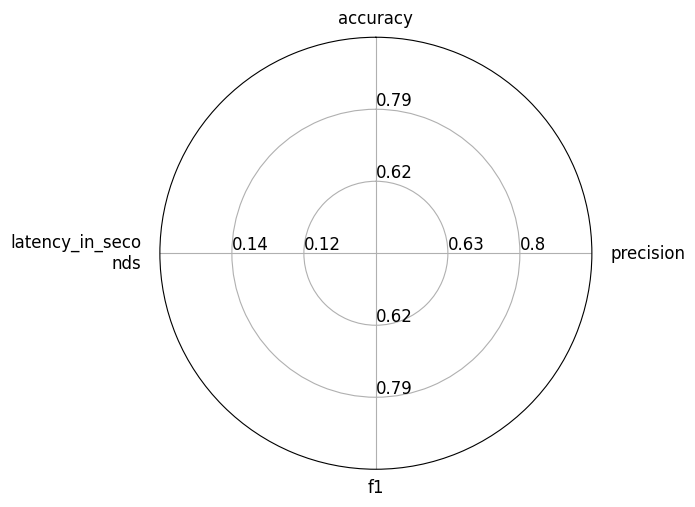

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from evaluate.visualization import radar_plot

data = [
    {"accuracy": 0.49, "precision": 0.50, "f1": 0.49, "latency_in_seconds": 0.15},
    {"accuracy": 0.92, "precision": 0.93, "f1": 0.92, "latency_in_seconds": 0.10},
    {"accuracy": 0.68, "precision": 0.70, "f1": 0.68, "latency_in_seconds": 0.12},
    {"accuracy": 0.78, "precision": 0.80, "f1": 0.78, "latency_in_seconds": 0.11}
]

model_names = ["Model 1", "Model 2", "Model 3", "Model 4"]

df_data = pd.DataFrame(data)

plot = radar_plot(data=df_data, model_names=model_names)

plt.show()

# 라이브러리 오류있음 